## _PyG: PyTorch Geometric_

A graph is used to model pairwise relations (edges) between objects (nodes). A single graph in PyG is described by an instance of torch_geometric.data.Data, which holds the following attributes by default:

- _`data.x`: Node feature matrix with shape `[num_nodes, num_node_features]`_
- _`data.edge_index`: Graph connectivity in COO format with shape `[2, num_edges]` and type `torch.long`_
- _`data.edge_attr`: Edge feature matrix with shape `[num_edges, num_edge_features]`_
- _`data.y`: Target to train against (may have arbitrary shape), _e.g._, node-level targets of shape `[num_nodes, *]` or graph-level targets of shape `[1, *]`_
- _`data.pos`: Node position matrix with shape `[num_nodes, num_dimensions]`_


In [1]:
import sys, os, glob, yaml

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
import pprint
from tqdm import tqdm
import trackml.dataset

In [4]:
import torch
from torch_geometric.data import Data

In [5]:
pp = pprint.PrettyPrinter(indent=2)

In [6]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
os.environ['EXATRKX_DATA'] = os.path.abspath(os.curdir)

### _PyG Data from GNN Stage_

In [7]:
# Read Event from the Testset
inputdir="run/gnn_evaluation/test"
outputdir="run/stt2_trkx/trkx_from_cc"
os.makedirs(outputdir, exist_ok=True)

In [8]:
all_files = glob.glob(os.path.join(inputdir, "*"))
all_files = sorted(all_files)
print("Total Test Events: ", len(all_files))

Total Test Events:  5000


In [9]:
all_files[:10]

['run/gnn_evaluation/test/5000',
 'run/gnn_evaluation/test/5001',
 'run/gnn_evaluation/test/5002',
 'run/gnn_evaluation/test/5003',
 'run/gnn_evaluation/test/5004',
 'run/gnn_evaluation/test/5005',
 'run/gnn_evaluation/test/5006',
 'run/gnn_evaluation/test/5007',
 'run/gnn_evaluation/test/5008',
 'run/gnn_evaluation/test/5009']

In [10]:
# Use One Event
filename = all_files[1]
evtid = int(os.path.basename(filename))
print("evtid: ", evtid)

evtid:  5001


In [11]:
data = torch.load(filename, map_location=device)

#### Explore the `PyD::Data`

In [12]:
print(data.keys)

['scores', 'y_pid', 'event_file', 'pt', 'layers', 'layerwise_true_edges', 'x', 'pid', 'hid', 'modulewise_true_edges', 'edge_index']


In [13]:
data.num_nodes, data.num_edges, data.num_features

(171, 2, 3)

In [14]:
data.is_directed()

True

In [15]:
'edge_attr' in data

False

In [16]:
# for key, item in data:
#    print(f'{key}, {item} found in Data')

In [17]:
data

Data(x=[171, 3], pid=[171], layers=[171], event_file='/global/cscratch1/sd/aakram/train_all/event0000095001', hid=[171], pt=[171], modulewise_true_edges=[2, 160], layerwise_true_edges=[2, 172], edge_index=[2, 808], y_pid=[808], scores=[1616])

In [18]:
# data.x or data['x']

In [19]:
# see https://stackoverflow.com/questions/19984102/select-elements-of-numpy-array-via-boolean-mask-array
true_edges = data.edge_index[:,data.y_pid]
true_edges.shape

torch.Size([2, 172])

In [20]:
false_edges = data.edge_index[:,~data.y_pid]
false_edges.shape

torch.Size([2, 636])

### _Plot PyG Data_

In [21]:
from src.drawing import detector_layout
from src.utils_math import polar_to_cartesian

In [22]:
r, phi, ir = data.x.T.detach().numpy()

In [23]:
# coord. transform, compensate scaling
x, y = polar_to_cartesian(r, phi)
ir = ir*100

### _Plot True Edges_

In [24]:
e = data.edge_index

In [25]:
# true_edges = e[:,data.y_pid]

In [26]:
# OR, try this
pid = data.pid
true_edges = pid[e[0]] == pid[e[1]]

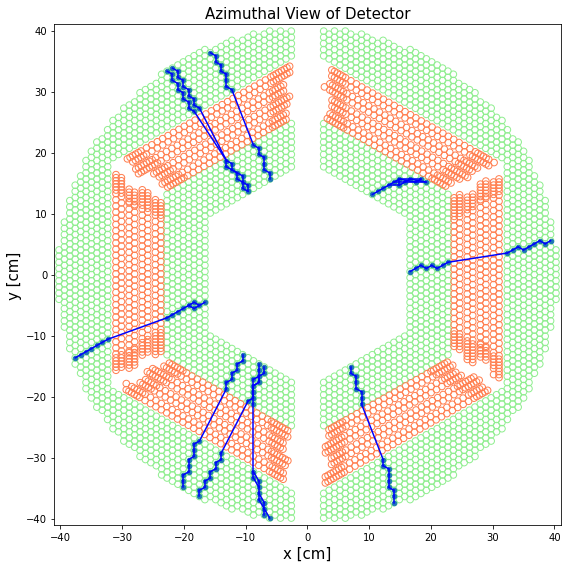

In [27]:
# plot only true edges
fig, ax = detector_layout(figsize=(8,8))

ax.plot(x[e[:, true_edges]], y[e[:, true_edges]], c="b")
ax.scatter(x, y, s=20)

ax.set_title("Azimuthal View of Detector", fontsize=15)
ax.grid(False)
fig.tight_layout()
# fig.savefig('true_edges_{}.png'.format(evtid))

### _Plot False Edges_

In [28]:
# false_edges = e[:,~data.y_pid]

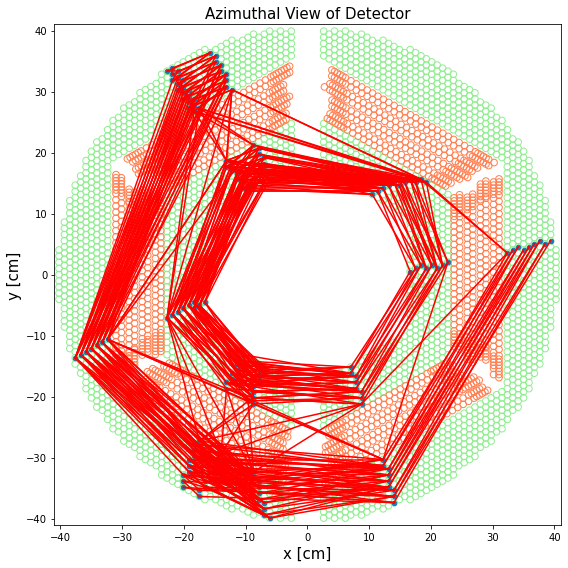

In [29]:
# plot only false edges
fig, ax = detector_layout(figsize=(8,8))

ax.plot(x[e[:, ~true_edges]], y[e[:, ~true_edges]], c="red")
ax.scatter(x, y, s=20)

ax.set_title("Azimuthal View of Detector", fontsize=15)
ax.grid(False)
fig.tight_layout()
# fig.savefig('false_edges_{}.png'.format(evtid))